In [18]:
import pandas as pd
import importlib

from UniversoActivos import UniversoActivosEstatico, UniversoActivosDinamico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
import Modelos
Modelos = importlib.reload(Modelos)
from Estrategia import EstrategiaMarkI, EstrategiaMLEquiponderada, EstrategiaMLMinVarAlphaTilt
from Backtest import BacktestEngine

RandomForestModel = Modelos.RandomForestModel
XGBoostModel = Modelos.XGBoostModel

# EURO STOXX 50

In [19]:
import pandas as pd
import requests

def get_eurostoxx50_tickers():
    url = 'https://en.wikipedia.org/wiki/EURO_STOXX_50'
    
    # Añadimos una cabecera para simular un navegador real
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }
    
    # Hacemos la petición con requests
    response = requests.get(url, headers=headers)
    
    # Pasamos el contenido HTML (response.text) a pandas
    tables = pd.read_html(response.text)
    
    # Buscamos la tabla que contiene la columna 'Ticker'
    df = next(table for table in tables if 'Ticker' in table.columns)
    
    return df['Ticker'].tolist()

# Ahora ya no debería dar error
tickers = get_eurostoxx50_tickers()
print(f"Total empresas: {len(tickers)}")
print(f"Muestra: {tickers[:5]}")

Total empresas: 50
Muestra: ['ADS.DE', 'ADYEN.AS', 'AD.AS', 'AI.PA', 'AIR.PA']


C:\Users\jpuerta\AppData\Local\Temp\ipykernel_39860\2238497255.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


## XGBoost + EstrategiaMLEquiponderada

$STLA.MI: possibly delisted; no timezone found
[*****                 10%                       ]  6 of 59 completed$STM.MI: possibly delisted; no timezone found
[********************  42%                       ]  25 of 59 completed$ENR.DE: possibly delisted; no price data found  (1d 2005-01-01 00:00:00 -> 2020-03-01) (Yahoo error = "Data doesn't exist for startDate = 1104534000, endDate = 1583017200")
[*********************100%***********************]  59 of 59 completed

3 Failed downloads:
['STLA.MI', 'STM.MI']: possibly delisted; no timezone found
['ENR.DE']: possibly delisted; no price data found  (1d 2005-01-01 00:00:00 -> 2020-03-01) (Yahoo error = "Data doesn't exist for startDate = 1104534000, endDate = 1583017200")
$STLA.MI: possibly delisted; no timezone found
[                       0%                       ]$ENR.DE: possibly delisted; no price data found  (1d 2005-01-01 00:00:00 -> 2020-03-01) (Yahoo error = "Data doesn't exist for startDate = 1104534000, endDate = 1583017

Modelo entrenado en fecha 2010-01-06
Modelo entrenado en fecha 2010-07-07
Modelo entrenado en fecha 2011-01-05
Modelo entrenado en fecha 2011-07-06
Modelo entrenado en fecha 2012-01-04
Modelo entrenado en fecha 2012-07-04
Modelo entrenado en fecha 2013-01-02
Modelo entrenado en fecha 2013-07-03
Modelo entrenado en fecha 2014-01-01
Modelo entrenado en fecha 2014-07-02
Modelo entrenado en fecha 2014-12-31
Modelo entrenado en fecha 2015-07-01
Modelo entrenado en fecha 2015-12-30
Modelo entrenado en fecha 2016-06-29
Modelo entrenado en fecha 2016-12-28
Modelo entrenado en fecha 2017-06-28
Modelo entrenado en fecha 2017-12-27
Modelo entrenado en fecha 2018-06-27
Modelo entrenado en fecha 2018-12-26
Modelo entrenado en fecha 2019-06-26
Modelo entrenado en fecha 2019-12-25


[*********************100%***********************]  1 of 1 completed


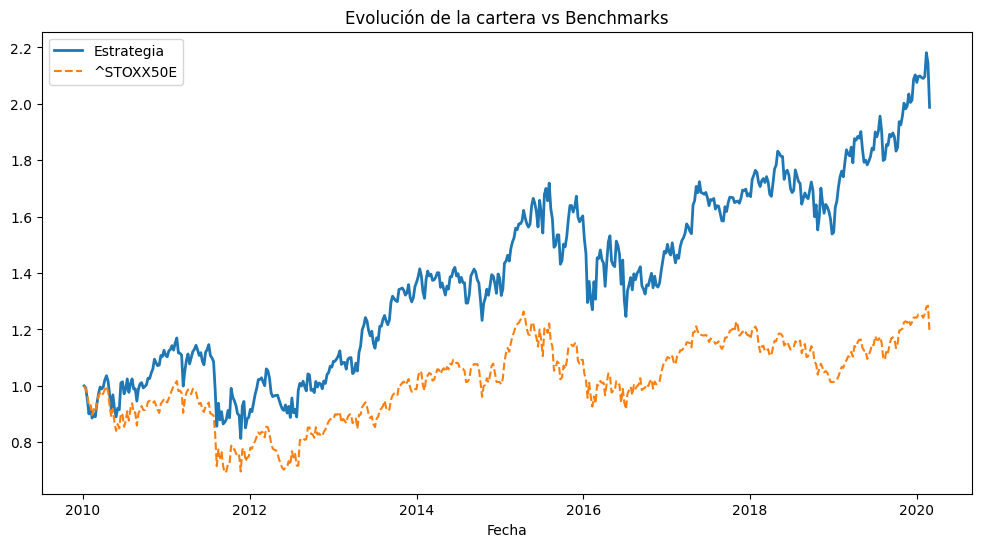

,Estrategia,^STOXX50E
Rentabilidad total,98.77%,18.87%
Rentabilidad anualizada,6.99%,1.71%
Volatilidad anualizada,22.71%,18.93%
Sharpe,0.41,0.18
Sortino,0.60,0.26
Max Drawdown,-30.45%,-31.96%
Calmar,0.23,0.05
Win rate,52.93%,53.50%
Mejor periodo,14.13%,12.65%
Peor periodo,-13.14%,-13.77%


In [20]:
start_date = "2010-01-01"
end_date = "2020-03-01"
universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date, end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=5, ticker_indice="SPY")
modelo = XGBoostModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0)
estrategia = EstrategiaMLEquiponderada(modelo=modelo, n_activos_obj=10, umbral_salida=15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=4,
    nominal=10000000
)

engine.print_results(bmks=["^STOXX50E"])

## XGBoost + EstrategiaMarkI

In [21]:
# modelo = XGBoostModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0)
# estrategia = EstrategiaMarkI(modelo=modelo, n_activos_obj=10, umbral_salida=15)
# engine = BacktestEngine(
#     universo=universo,
#     proveedor=proveedor,
#     feature_engineer=fe,
#     estrategia=estrategia,
#     start_date="2021-01-01",
#     end_date="2026-03-01",
#     len_ventana=4,
#     nominal=10000000
# )

# engine.print_results(bmks=["^STOXX50E"])

## Random Forest + EstrategiaMLEquiponderada

$STLA.MI: possibly delisted; no timezone found
[******                12%                       ]  7 of 59 completed$STM.MI: possibly delisted; no timezone found
[***********           22%                       ]  13 of 59 completed$ENR.DE: possibly delisted; no price data found  (1d 2005-01-01 00:00:00 -> 2020-03-01) (Yahoo error = "Data doesn't exist for startDate = 1104534000, endDate = 1583017200")
[*********************100%***********************]  59 of 59 completed

3 Failed downloads:
['STLA.MI', 'STM.MI']: possibly delisted; no timezone found
['ENR.DE']: possibly delisted; no price data found  (1d 2005-01-01 00:00:00 -> 2020-03-01) (Yahoo error = "Data doesn't exist for startDate = 1104534000, endDate = 1583017200")
$STLA.MI: possibly delisted; no timezone found
[*******               15%                       ]  9 of 59 completed$STM.MI: possibly delisted; no timezone found
[***********           22%                       ]  13 of 59 completed$ENR.DE: possibly delisted; no pr

Modelo entrenado en fecha 2010-01-06
Modelo entrenado en fecha 2010-07-07
Modelo entrenado en fecha 2011-01-05
Modelo entrenado en fecha 2011-07-06
Modelo entrenado en fecha 2012-01-04
Modelo entrenado en fecha 2012-07-04
Modelo entrenado en fecha 2013-01-02
Modelo entrenado en fecha 2013-07-03
Modelo entrenado en fecha 2014-01-01
Modelo entrenado en fecha 2014-07-02
Modelo entrenado en fecha 2014-12-31
Modelo entrenado en fecha 2015-07-01
Modelo entrenado en fecha 2015-12-30
Modelo entrenado en fecha 2016-06-29
Modelo entrenado en fecha 2016-12-28
Modelo entrenado en fecha 2017-06-28
Modelo entrenado en fecha 2017-12-27
Modelo entrenado en fecha 2018-06-27
Modelo entrenado en fecha 2018-12-26
Modelo entrenado en fecha 2019-06-26
Modelo entrenado en fecha 2019-12-25


[*********************100%***********************]  1 of 1 completed


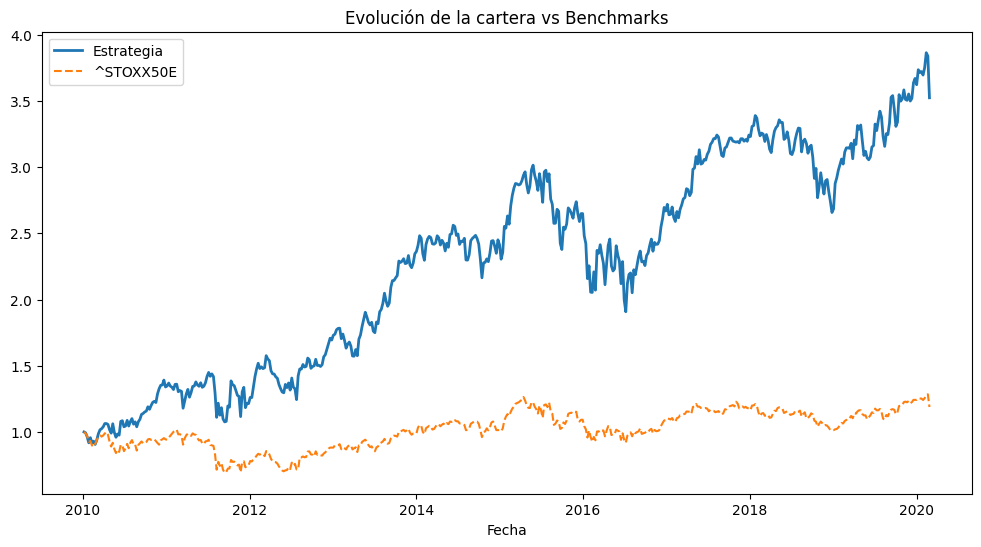

,Estrategia,^STOXX50E
Rentabilidad total,252.35%,18.87%
Rentabilidad anualizada,13.18%,1.71%
Volatilidad anualizada,26.02%,18.93%
Sharpe,0.61,0.18
Sortino,0.92,0.26
Max Drawdown,-36.71%,-31.96%
Calmar,0.36,0.05
Win rate,55.95%,53.50%
Mejor periodo,16.78%,12.65%
Peor periodo,-14.21%,-13.77%


In [22]:
modelo = RandomForestModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0)
estrategia = EstrategiaMLEquiponderada(modelo=modelo, n_activos_obj=10, umbral_salida=15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=4,
    nominal=10000000
)

engine.print_results(bmks=["^STOXX50E"])

## Random Forest + EstrategiaMLMinVarAlphaTilt

$STLA.MI: possibly delisted; no timezone found
[******                12%                       ]  7 of 59 completed$STM.MI: possibly delisted; no timezone found
[***********           22%                       ]  13 of 59 completed$ENR.DE: possibly delisted; no price data found  (1d 2005-01-01 00:00:00 -> 2020-03-01) (Yahoo error = "Data doesn't exist for startDate = 1104534000, endDate = 1583017200")
[*********************100%***********************]  59 of 59 completed

3 Failed downloads:
['STLA.MI', 'STM.MI']: possibly delisted; no timezone found
['ENR.DE']: possibly delisted; no price data found  (1d 2005-01-01 00:00:00 -> 2020-03-01) (Yahoo error = "Data doesn't exist for startDate = 1104534000, endDate = 1583017200")
$STLA.MI: possibly delisted; no timezone found
[                       0%                       ]$ENR.DE: possibly delisted; no price data found  (1d 2005-01-01 00:00:00 -> 2020-03-01) (Yahoo error = "Data doesn't exist for startDate = 1104534000, endDate = 1583017

Modelo entrenado en fecha 2010-01-06
Modelo entrenado en fecha 2010-07-07
Modelo entrenado en fecha 2011-01-05
Modelo entrenado en fecha 2011-07-06
Modelo entrenado en fecha 2012-01-04
Modelo entrenado en fecha 2012-07-04
Modelo entrenado en fecha 2013-01-02
Modelo entrenado en fecha 2013-07-03
Modelo entrenado en fecha 2014-01-01
Modelo entrenado en fecha 2014-07-02
Modelo entrenado en fecha 2014-12-31
Modelo entrenado en fecha 2015-07-01
Modelo entrenado en fecha 2015-12-30
Modelo entrenado en fecha 2016-06-29
Modelo entrenado en fecha 2016-12-28
Modelo entrenado en fecha 2017-06-28
Modelo entrenado en fecha 2017-12-27
Modelo entrenado en fecha 2018-06-27
Modelo entrenado en fecha 2018-12-26
Modelo entrenado en fecha 2019-06-26
Modelo entrenado en fecha 2019-12-25


[*********************100%***********************]  1 of 1 completed


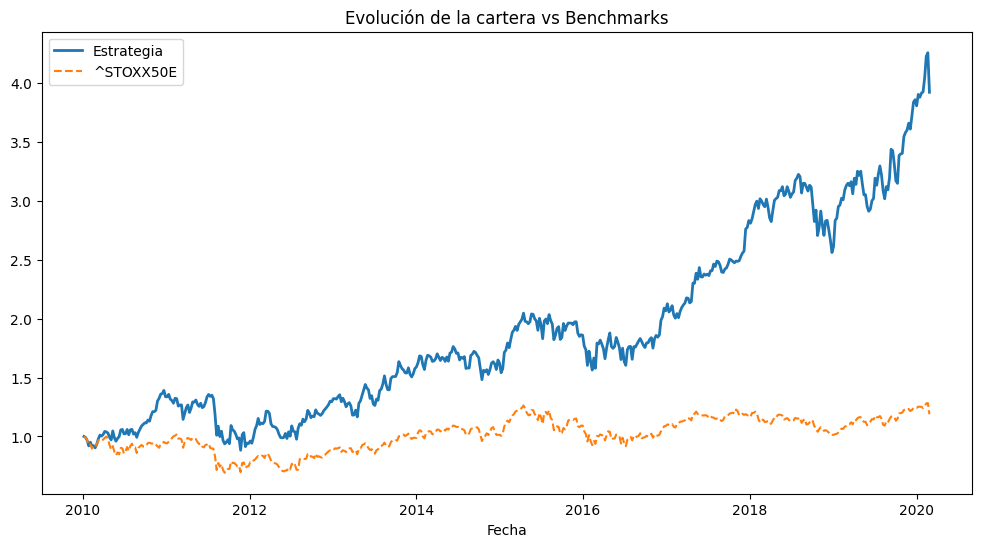

,Estrategia,^STOXX50E
Rentabilidad total,292.39%,18.87%
Rentabilidad anualizada,14.38%,1.71%
Volatilidad anualizada,25.40%,18.93%
Sharpe,0.66,0.18
Sortino,1.00,0.26
Max Drawdown,-36.54%,-31.96%
Calmar,0.39,0.05
Win rate,54.25%,53.50%
Mejor periodo,16.36%,12.65%
Peor periodo,-14.78%,-13.77%


In [23]:
modelo = RandomForestModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0)

estrategia = EstrategiaMLMinVarAlphaTilt(
    modelo=modelo,
    n_activos_obj=10,
    umbral_salida=15,      # universo candidato para optimización
    p_neutral=0.55,        # más conservador que 0.50
    alpha_scale=1.0,
    lambda_risk=3.0,       # subir para bajar volatilidad
    lambda_tc=0.001,       # subir para rotar menos
    w_max=0.15,
    turnover_max=0.20,
    no_trade_band=0.002,   # 40 bps de banda
    coste_transaccion=0.0005,  # 5 bps
    utility_buffer=0.0001,     # histéresis adicional
    min_hist_obs=26
)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=4,
    nominal=10000000
)

engine.print_results(bmks=["^STOXX50E"])

## XGBoostModel + EstrategiaMLMinVarAlphaTilt

$STLA.MI: possibly delisted; no timezone found
[*******               14%                       ]  8 of 59 completed$STM.MI: possibly delisted; no timezone found
[************          24%                       ]  14 of 59 completed$ENR.DE: possibly delisted; no price data found  (1d 2005-01-01 00:00:00 -> 2020-03-01) (Yahoo error = "Data doesn't exist for startDate = 1104534000, endDate = 1583017200")
[*********************100%***********************]  59 of 59 completed

3 Failed downloads:
['STLA.MI', 'STM.MI']: possibly delisted; no timezone found
['ENR.DE']: possibly delisted; no price data found  (1d 2005-01-01 00:00:00 -> 2020-03-01) (Yahoo error = "Data doesn't exist for startDate = 1104534000, endDate = 1583017200")
$STLA.MI: possibly delisted; no timezone found
[*****                 10%                       ]  6 of 59 completed$STM.MI: possibly delisted; no timezone found
[***********           22%                       ]  13 of 59 completed$ENR.DE: possibly delisted; no pr

Modelo entrenado en fecha 2010-01-06
Modelo entrenado en fecha 2010-07-07
Modelo entrenado en fecha 2011-01-05
Modelo entrenado en fecha 2011-07-06
Modelo entrenado en fecha 2012-01-04
Modelo entrenado en fecha 2012-07-04
Modelo entrenado en fecha 2013-01-02
Modelo entrenado en fecha 2013-07-03
Modelo entrenado en fecha 2014-01-01
Modelo entrenado en fecha 2014-07-02
Modelo entrenado en fecha 2014-12-31
Modelo entrenado en fecha 2015-07-01
Modelo entrenado en fecha 2015-12-30
Modelo entrenado en fecha 2016-06-29
Modelo entrenado en fecha 2016-12-28
Modelo entrenado en fecha 2017-06-28
Modelo entrenado en fecha 2017-12-27
Modelo entrenado en fecha 2018-06-27
Modelo entrenado en fecha 2018-12-26
Modelo entrenado en fecha 2019-06-26
Modelo entrenado en fecha 2019-12-25


[*********************100%***********************]  1 of 1 completed


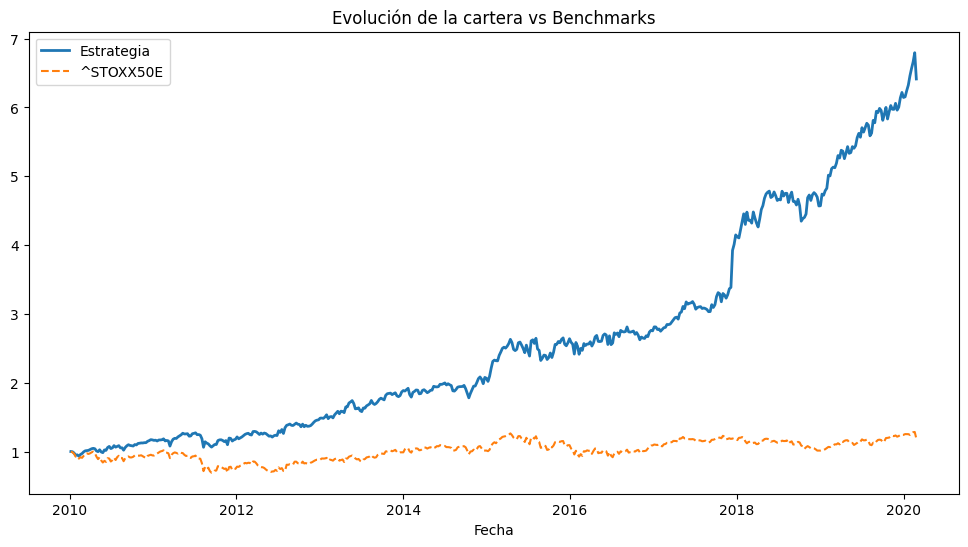

,Estrategia,^STOXX50E
Rentabilidad total,541.32%,18.87%
Rentabilidad anualizada,20.04%,1.71%
Volatilidad anualizada,16.71%,18.93%
Sharpe,1.18,0.18
Sortino,1.93,0.26
Max Drawdown,-16.48%,-31.96%
Calmar,1.22,0.05
Win rate,59.74%,53.50%
Mejor periodo,15.89%,12.65%
Peor periodo,-10.42%,-13.77%


In [24]:
modelo = XGBoostModel(
    n_estimators=300,
    max_depth=4,
    positive_class_weight=8.0
)

estrategia = EstrategiaMLMinVarAlphaTilt(
    modelo=modelo,
    n_activos_obj=10,
    umbral_salida=15,      # universo candidato para optimización
    p_neutral=0.55,        # más conservador que 0.50
    alpha_scale=1.0,
    lambda_risk=3.0,       # subir para bajar volatilidad
    lambda_tc=0.001,       # subir para rotar menos
    w_max=0.15,
    turnover_max=0.20,
    no_trade_band=0.002,   # 40 bps de banda
    coste_transaccion=0.0005,  # 5 bps
    utility_buffer=0.0001,     # histéresis adicional
    min_hist_obs=26
)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=4,
    nominal=10000000
)

engine.print_results(bmks=["^STOXX50E"])

# Cartera de ETFs por sectores

In [8]:
csv_path = r"pipelineJC\data\etfs_by_sector_industry_commodity.csv"

df = pd.read_csv(csv_path)
tickers = df["Ticker"].dropna().astype(str).str.strip().unique().tolist()

## XGBoost + EstrategiaMLEquiponderada

In [9]:
universo = UniversoActivosEstatico(tickers=tickers)
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=5, ticker_indice="SPY")
modelo = XGBoostModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0)
estrategia = EstrategiaMLEquiponderada(modelo=modelo, n_activos_obj=10, umbral_salida=15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date="2021-01-01",
    end_date="2026-03-01",
    len_ventana=4,
    nominal=10000000
)

engine.print_results(bmk_equal_weight=tickers)

[*********************100%***********************]  40 of 40 completed
[*********************100%***********************]  40 of 40 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:48: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(Precio_Close=("Precio_Close", "last"), Volumen_USD=("Volumen_USD", "sum")).reset_index()


Modelo entrenado en fecha 2021-01-06
Modelo entrenado en fecha 2021-07-07
Modelo entrenado en fecha 2022-01-05
Modelo entrenado en fecha 2022-07-06
Modelo entrenado en fecha 2023-01-04
Modelo entrenado en fecha 2023-07-05


ValueError: cannot convert float NaN to integer

## XGBoost + EstrategiaMarkI

In [ ]:
# modelo = XGBoostModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0)
# estrategia = EstrategiaMarkI(modelo=modelo, n_activos_obj=10, umbral_salida=15)
# engine = BacktestEngine(
#     universo=universo,
#     proveedor=proveedor,
#     feature_engineer=fe,
#     estrategia=estrategia,
#     start_date="2021-01-01",
#     end_date="2026-03-01",
#     len_ventana=4,
#     nominal=10000000
# )

# engine.print_results(bmks=["^STOXX50E"])

## RandomForestModel + EstrategiaMLEquiponderada

[*********************100%***********************]  40 of 40 completed
[*********************100%***********************]  40 of 40 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:48: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(Precio_Close=("Precio_Close", "last"), Volumen_USD=("Volumen_USD", "sum")).reset_index()


Modelo entrenado en fecha 2021-01-06
Modelo entrenado en fecha 2021-07-07
Modelo entrenado en fecha 2022-01-05
Modelo entrenado en fecha 2022-07-06
Modelo entrenado en fecha 2023-01-04
Modelo entrenado en fecha 2023-07-05
Modelo entrenado en fecha 2024-01-03
Modelo entrenado en fecha 2024-07-03
Modelo entrenado en fecha 2025-01-01
Modelo entrenado en fecha 2025-07-02
Modelo entrenado en fecha 2025-12-31


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  40 of 40 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Backtest.py:189: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  serie_ew = (1 + precios.pct_change().mean(axis=1, skipna=True).fillna(0)).cumprod()


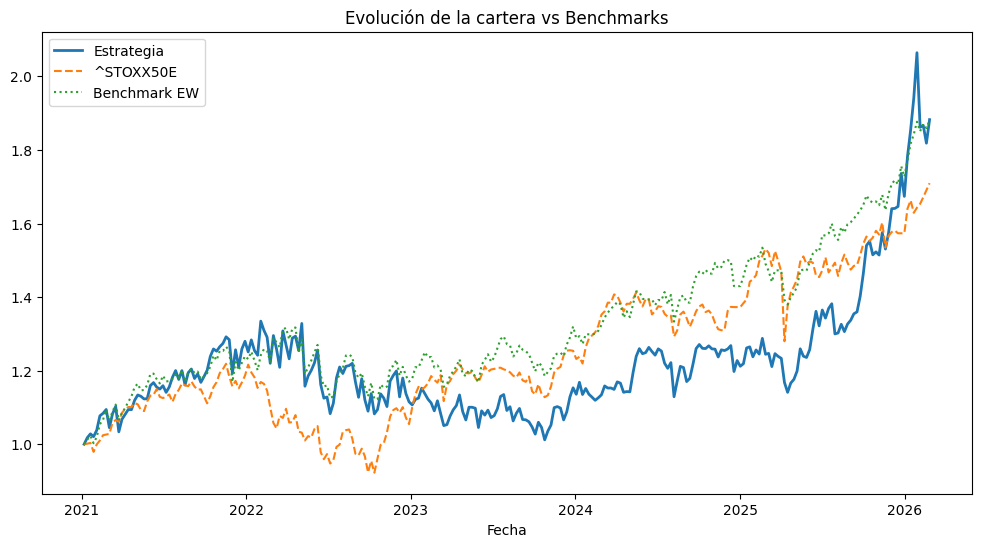

,Estrategia,^STOXX50E,Benchmark EW
Rentabilidad total,88.24%,70.95%,88.02%
Rentabilidad anualizada,13.06%,10.96%,13.03%
Volatilidad anualizada,21.43%,14.83%,14.13%
Sharpe,0.68,0.78,0.94
Sortino,0.98,1.08,1.32
Max Drawdown,-24.17%,-24.30%,-14.81%
Calmar,0.54,0.45,0.88
Win rate,57.09%,58.96%,59.33%
Mejor periodo,8.20%,7.45%,5.25%
Peor periodo,-12.84%,-12.85%,-7.25%


In [ ]:
modelo = RandomForestModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0)
estrategia = EstrategiaMLEquiponderada(modelo=modelo, n_activos_obj=10, umbral_salida=15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date="2021-01-01",
    end_date="2026-03-01",
    len_ventana=4,
    nominal=10000000
)

engine.print_results(bmks=["^STOXX50E"], bmk_equal_weight=tickers)

## Random Forest + EstrategiaMLMinVarAlphaTilt

In [ ]:
modelo = RandomForestModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0)

estrategia = EstrategiaMLMinVarAlphaTilt(
    modelo=modelo,
    n_activos_obj=10,
    umbral_salida=15,      # universo candidato para optimización
    p_neutral=0.55,        # más conservador que 0.50
    alpha_scale=1.0,
    lambda_risk=3.0,       # subir para bajar volatilidad
    lambda_tc=0.001,       # subir para rotar menos
    w_max=0.15,
    turnover_max=0.20,
    no_trade_band=0.002,   # 40 bps de banda
    coste_transaccion=0.0005,  # 5 bps
    utility_buffer=0.0001,     # histéresis adicional
    min_hist_obs=26
)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date="2021-01-01",
    end_date="2026-03-01",
    len_ventana=4,
    nominal=10000000
)

engine.print_results(bmks=["^STOXX50E"], bmk_equal_weight=tickers)

[*********************100%***********************]  40 of 40 completed
[*********************100%***********************]  40 of 40 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:48: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(Precio_Close=("Precio_Close", "last"), Volumen_USD=("Volumen_USD", "sum")).reset_index()


Modelo entrenado en fecha 2021-01-06
Modelo entrenado en fecha 2021-07-07
Modelo entrenado en fecha 2022-01-05
Modelo entrenado en fecha 2022-07-06
Modelo entrenado en fecha 2023-01-04
Modelo entrenado en fecha 2023-07-05


ValueError: cannot convert float NaN to integer

## XGBoostModel + EstrategiaMLMinVarAlphaTilt

In [ ]:
modelo = XGBoostModel(
    n_estimators=300,
    max_depth=4,
    positive_class_weight=8.0
)

estrategia = EstrategiaMLMinVarAlphaTilt(
    modelo=modelo,
    n_activos_obj=10,
    umbral_salida=15,      # universo candidato para optimización
    p_neutral=0.55,        # más conservador que 0.50
    alpha_scale=1.0,
    lambda_risk=3.0,       # subir para bajar volatilidad
    lambda_tc=0.001,       # subir para rotar menos
    w_max=0.15,
    turnover_max=0.20,
    no_trade_band=0.002,   # 40 bps de banda
    coste_transaccion=0.0005,  # 5 bps
    utility_buffer=0.0001,     # histéresis adicional
    min_hist_obs=26
)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date="2021-01-01",
    end_date="2026-03-01",
    len_ventana=4,
    nominal=10000000
)

engine.print_results(bmks=["^STOXX50E"])